In [2]:

import numpy as np

import requests
import pandas as pd
from datetime import datetime, timedelta


ModuleNotFoundError: No module named 'pandas'

In [105]:
start_date = "2023-11-09T00:00:00+00:00"
end_date = "2024-11-11T23:59:00+00:00"
ohlcv_api_key = 'r65B9O5aplSJn7BWSo8z8pNH8v2wW5yc'
ticker = "AAPL"
#file_path = r"C:\Users\revan\Desktop\BlockHouse\Files\XNAS-20241115-DCHWGR8MVR\xnas-itch-20231109-20241109.mbp-10.csv"

In [112]:
def preprocess_l2_data(file_path, chunk_size=500000):
    chunks = []
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        
        if 'symbol' not in chunk.columns:
            chunk['symbol'] = "AAPL"
        if chunk['ts_recv'].dtype == 'int64':  # Check if it's a Unix timestamp (in nanoseconds)
            # Convert Unix timestamp (nanoseconds) to datetime in UTC
            chunk['ts_recv'] = pd.to_datetime(chunk['ts_recv'] / 1e6, unit='ms', utc=True)
        else:
            # If it's in ISO8601 format, parse it as before
            chunk['ts_recv'] = pd.to_datetime(chunk['ts_recv'], format='%Y-%m-%dT%H:%M:%S.%fZ', utc=True)
        #chunk['ts_recv'] = pd.to_datetime(chunk['ts_recv'], format='%Y-%m-%dT%H:%M:%S.%fZ')
        
        # Filter for market-opening trade records (9:30 - 16:00 EST) and convert to UTC
        est_start = pd.to_datetime('13:30:00', format='%H:%M:%S').time()
        est_end = pd.to_datetime('20:00:00', format='%H:%M:%S').time()
        chunk = chunk[(chunk['ts_recv'].dt.time >= est_start) & (chunk['ts_recv'].dt.time <= est_end)]
        #chunk['ts_recv'] = chunk['ts_recv'].dt.tz_localize('America/New_York').dt.tz_convert('UTC')
        # Check if the 'ts_recv' column is timezone-aware before localizing to 'America/New_York'
        if chunk['ts_recv'].dt.tz is None:
            # If naive, localize to 'America/New_York'
            chunk['ts_recv'] = chunk['ts_recv'].dt.tz_localize('America/New_York')
        else:
            # If already timezone-aware, just convert
            chunk['ts_recv'] = chunk['ts_recv'].dt.tz_convert('America/New_York')
        # Convert to UTC
        chunk['ts_recv'] = chunk['ts_recv'].dt.tz_convert('UTC')
        # Create a minute-level timestamp
        chunk['minute'] = chunk['ts_recv'].dt.floor('min')
        
        # For each minute, select the row with the maximum depth
        max_depth_chunk = chunk.loc[chunk.groupby('minute')['depth'].idxmax()]
        
        # Drop duplicates in case of multiple rows with the same max depth in a minute
        max_depth_chunk = max_depth_chunk.drop_duplicates(subset=['minute'])
        
        # Append processed chunk to list
        chunks.append(max_depth_chunk[['minute', 'depth', 'symbol', 'bid_px_00', 'bid_sz_00', 'bid_px_01', 'bid_sz_01',
                                       'bid_px_02', 'bid_sz_02', 'bid_px_03', 'bid_sz_03', 'bid_px_04', 'bid_sz_04',
                                       'bid_px_05', 'bid_sz_05', 'bid_px_06', 'bid_sz_06', 'bid_px_07', 'bid_sz_07',
                                       'bid_px_08', 'bid_sz_08', 'bid_px_09', 'bid_sz_09', 'ask_px_00', 'ask_sz_00',
                                       'ask_px_01', 'ask_sz_01', 'ask_px_02', 'ask_sz_02', 'ask_px_03', 'ask_sz_03',
                                       'ask_px_04', 'ask_sz_04', 'ask_px_05', 'ask_sz_05', 'ask_px_06', 'ask_sz_06',
                                       'ask_px_07', 'ask_sz_07', 'ask_px_08', 'ask_sz_08', 'ask_px_09', 'ask_sz_09']])
    
    # Concatenate all chunks into a single DataFrame
    processed_data = pd.concat(chunks, ignore_index=True)
    return processed_data


In [113]:
import requests
import pandas as pd
from datetime import datetime, timedelta

def get_ohlcv(api_key, ticker, start_date, end_date):
    def get_data_for_date_range(start_date, end_date):
        # Format start and end dates correctly
        start_date_formatted = start_date.split("T")[0]  # Extract date part in YYYY-MM-DD format
        end_date_formatted = end_date.split("T")[0]      # Extract date part in YYYY-MM-DD format
        
        print(f"Fetching data for {ticker} from {start_date_formatted} to {end_date_formatted}")
        
        url = f"https://api.polygon.io/v2/aggs/ticker/{ticker}/range/1/minute/{start_date_formatted}/{end_date_formatted}?apiKey={api_key}"
        print(f"Request URL: {url}")  # Debugging: Print the request URL
        response = requests.get(url)
        
        try:
            response.raise_for_status()
        except requests.exceptions.HTTPError as err:
            print(f"HTTP error occurred: {err}")
            print(f"Response content: {response.content}")
            return None
        
        data = response.json()
        
        if 'results' not in data:
            print(f"Unexpected response format: {data}")
            return None
        
        # Convert results into a DataFrame
        df_poly_ohlcv = pd.DataFrame(data['results'])
        df_poly_ohlcv['timestamp'] = pd.to_datetime(df_poly_ohlcv['t'], unit='ms', utc=True)
        df_poly_ohlcv.drop(columns=['t', 'vw'], inplace=True)

        df_poly_ohlcv.rename(columns={'o': 'open', 'c': 'close', 'h': 'high', 'l': 'low', 'v': 'volume', 'n': 'transactions'}, inplace=True)
        df_poly_ohlcv.set_index('timestamp', inplace=True)
        
        # Filter based on time range in UTC and ensure timezone consistency
        df_poly_ohlcv_filtered = df_poly_ohlcv.between_time('13:30', '20:00')  # Time range in UTC
        df_poly_ohlcv_filtered.index = df_poly_ohlcv_filtered.index.tz_convert('UTC')  # Ensure UTC
        
        # Reset index for final DataFrame
        df_poly_ohlcv_filtered.reset_index(inplace=True)
        return df_poly_ohlcv_filtered

    # Initialize an empty list to store the chunks
    all_data = []
    
    # Loop through the date range in chunks of 7 days
    current_start_date = datetime.strptime(start_date, '%Y-%m-%dT%H:%M:%S+00:00')
    current_end_date = current_start_date + timedelta(days=7)
    
    while current_start_date <= datetime.strptime(end_date, '%Y-%m-%dT%H:%M:%S+00:00'):
        # Format the current dates in the correct format
        start_date_str = current_start_date.strftime('%Y-%m-%dT%H:%M:%S+00:00')
        end_date_str = min(current_end_date, datetime.strptime(end_date, '%Y-%m-%dT%H:%M:%S+00:00')).strftime('%Y-%m-%dT%H:%M:%S+00:00')
        
        # Get the data for the current chunk
        chunk_data = get_data_for_date_range(start_date_str, end_date_str)
        
        if chunk_data is not None:
            all_data.append(chunk_data)
        
        # Move to the next chunk
        current_start_date = current_end_date 
        current_end_date = current_start_date + timedelta(days=7)
    
    # Concatenate all data chunks into a single DataFrame
    if all_data:
        final_data = pd.concat(all_data, ignore_index=True)
        
        # Convert the 'timestamp' field to UTC, ensuring consistency
        final_data['timestamp'] = final_data['timestamp'].dt.tz_convert('UTC')
        return final_data
    else:
        print("No data found.")
        return None


In [114]:
def calculate_rolling_volatility(stock_data, window_size=20):
    stock_data['mid_price'] = (stock_data['high'] + stock_data['low']) / 2  # Calculate mid-price using High and Low
    stock_data['Volatility'] = stock_data['mid_price'].rolling(window=window_size).std()  # Rolling standard deviation
    return stock_data


In [115]:
#processed_data=preprocess_l2_data(file_path)
def process_multiple_files(file_paths, chunk_size=500000):
    # Create an empty DataFrame to store all the processed data
    all_processed_data = pd.DataFrame()
    
    # Iterate over each file path in the list
    for file_path in file_paths:
        # Call preprocess_l2_data function with the current file path
        processed_data = preprocess_l2_data(file_path, chunk_size)
        
        # Append the processed data to the all_processed_data DataFrame
        all_processed_data = pd.concat([all_processed_data, processed_data], ignore_index=True)
        
        print(f"Processed data for file: {file_path}")

    # Remove duplicates from the combined DataFrame
    all_processed_data = all_processed_data.drop_duplicates()
    
    # Return the combined DataFrame containing data from all files
    return all_processed_data
    

In [ ]:
file_path=[
    r'C:\Users\revan\Desktop\BlockHouse\Files\XNAS-20241116-FWMHYXSYKP\xnas-itch-20231109-20240209.mbp-10.csv\xnas-itch-20231109-20240209.mbp-10.csv',
    r'C:\Users\revan\Desktop\BlockHouse\Files\XNAS-20241116-NVHJWJ97Y8\xnas-itch-20240210-20240608.mbp-10.csv',
    r'C:\Users\revan\Desktop\BlockHouse\Files\XNAS-20241115-UB9RU6T9CJ\xnas-itch-20240609-20241009.mbp-10.csv',
    r'C:\Users\revan\Desktop\BlockHouse\Files\XNAS-20241119-VUET876PKS\xnas-itch-20240901-20241110.mbp-10.csv\xnas-itch-20240901-20241110.mbp-10.csv'
]

processed_data=process_multiple_files(file_path)

Processed data for file: C:\Users\revan\Desktop\BlockHouse\Files\XNAS-20241116-FWMHYXSYKP\xnas-itch-20231109-20240209.mbp-10.csv\xnas-itch-20231109-20240209.mbp-10.csv
Processed data for file: C:\Users\revan\Desktop\BlockHouse\Files\XNAS-20241116-NVHJWJ97Y8\xnas-itch-20240210-20240608.mbp-10.csv
Processed data for file: C:\Users\revan\Desktop\BlockHouse\Files\XNAS-20241115-UB9RU6T9CJ\xnas-itch-20240609-20241009.mbp-10.csv
Processed data for file: C:\Users\revan\Desktop\BlockHouse\Files\XNAS-20241119-VUET876PKS\xnas-itch-20240901-20241110.mbp-10.csv\xnas-itch-20240901-20241110.mbp-10.csv


In [121]:
processed_data.head()

,minute,depth,symbol,bid_px_00,bid_sz_00,bid_px_01,bid_sz_01,bid_px_02,bid_sz_02,bid_px_03,...,ask_px_05,ask_sz_05,ask_px_06,ask_sz_06,ask_px_07,ask_sz_07,ask_px_08,ask_sz_08,ask_px_09,ask_sz_09
0,2023-11-09 13:30:00+00:00,0,AAPL,1.823500e+11,4.0,1.823000e+11,1.0,1.822500e+11,7.0,1.822400e+11,...,1.826700e+11,1.0,1.826900e+11,90.0,1.827200e+11,15.0,1.827300e+11,1.0,1.827800e+11,2.0
1,2023-11-09 13:31:00+00:00,5,AAPL,1.823500e+11,4.0,1.823000e+11,1.0,1.822500e+11,7.0,1.822400e+11,...,1.826500e+11,103.0,1.826700e+11,1.0,1.826900e+11,90.0,1.827200e+11,15.0,1.827300e+11,1.0
2,2023-11-09 13:32:00+00:00,9,AAPL,1.823500e+11,4.0,1.823000e+11,1.0,1.822500e+11,7.0,1.822400e+11,...,1.826500e+11,103.0,1.826700e+11,1.0,1.826900e+11,90.0,1.827200e+11,15.0,1.827300e+11,3.0
3,2023-11-09 13:33:00+00:00,1,AAPL,1.822600e+11,1.0,1.822500e+11,7.0,1.822400e+11,1.0,1.822100e+11,...,1.825400e+11,50.0,1.825900e+11,4.0,1.826000e+11,107.0,1.826500e+11,103.0,1.826700e+11,1.0
4,2023-11-09 13:34:00+00:00,7,AAPL,1.822100e+11,150.0,1.822000e+11,251.0,1.821000e+11,409.0,1.820900e+11,...,1.825900e+11,4.0,1.826000e+11,107.0,1.826500e+11,103.0,1.826700e+11,1.0,1.826900e+11,90.0


In [120]:
processed_data.to_csv(r'C:\Users\revan\Desktop\BlockHouse\Repo\Blockhouse\Data-Curation\L2 Preprocessing\preprocessed2.csv', index=False)

In [123]:
import pandas as pd
import numpy as np

# Load the data
#df = pd.read_csv(r'C:\Users\revan\Desktop\BlockHouse\Repo\Blockhouse\Data-Curation\L2 Preprocessing\output2.csv', sep=',',header=0)
print(processed_data.columns.tolist())
# Define bid and ask price columns
bid_price_cols = [f'bid_px_{i:02d}' for i in range(10)]
ask_price_cols = [f'ask_px_{i:02d}' for i in range(10)]
fixed_point_cols = bid_price_cols + ask_price_cols

# Function to conditionally scale values
def conditional_scale(value, threshold=1e5):
    try:
        if value > threshold:
            return value / 1e9
        return value
    except:
        return np.nan  # Handle any unexpected errors

# Apply scaling
for col in fixed_point_cols:
    processed_data[col] = pd.to_numeric(processed_data[col], errors='coerce')  # Convert to numeric, set errors to NaN
    processed_data[col] = processed_data[col].apply(lambda x: conditional_scale(x) if pd.notnull(x) else x)

# Verify scaling
print(processed_data[fixed_point_cols].head())

# Save the cleaned data
processed_data.to_csv(r'C:\Users\revan\Desktop\BlockHouse\Repo\Blockhouse\Data-Curation\L2 Preprocessing\cleaned_data2.csv', index=False, sep=',')


['minute', 'depth', 'symbol', 'bid_px_00', 'bid_sz_00', 'bid_px_01', 'bid_sz_01', 'bid_px_02', 'bid_sz_02', 'bid_px_03', 'bid_sz_03', 'bid_px_04', 'bid_sz_04', 'bid_px_05', 'bid_sz_05', 'bid_px_06', 'bid_sz_06', 'bid_px_07', 'bid_sz_07', 'bid_px_08', 'bid_sz_08', 'bid_px_09', 'bid_sz_09', 'ask_px_00', 'ask_sz_00', 'ask_px_01', 'ask_sz_01', 'ask_px_02', 'ask_sz_02', 'ask_px_03', 'ask_sz_03', 'ask_px_04', 'ask_sz_04', 'ask_px_05', 'ask_sz_05', 'ask_px_06', 'ask_sz_06', 'ask_px_07', 'ask_sz_07', 'ask_px_08', 'ask_sz_08', 'ask_px_09', 'ask_sz_09']
   bid_px_00  bid_px_01  bid_px_02  bid_px_03  bid_px_04  bid_px_05  \
0     182.35     182.30     182.25     182.24     182.21     182.20   
1     182.35     182.30     182.25     182.24     182.21     182.20   
2     182.35     182.30     182.25     182.24     182.21     182.20   
3     182.26     182.25     182.24     182.21     182.20     182.10   
4     182.21     182.20     182.10     182.09     182.05     182.03   

   bid_px_06  bid_px_07

In [124]:
# Step 2: Fetch OHLCV data from Polygon
df_ohlcv = get_ohlcv(ohlcv_api_key, ticker, start_date, end_date)

Fetching data for AAPL from 2023-11-09 to 2023-11-16
Request URL: https://api.polygon.io/v2/aggs/ticker/AAPL/range/1/minute/2023-11-09/2023-11-16?apiKey=r65B9O5aplSJn7BWSo8z8pNH8v2wW5yc
Fetching data for AAPL from 2023-11-16 to 2023-11-23
Request URL: https://api.polygon.io/v2/aggs/ticker/AAPL/range/1/minute/2023-11-16/2023-11-23?apiKey=r65B9O5aplSJn7BWSo8z8pNH8v2wW5yc
Fetching data for AAPL from 2023-11-23 to 2023-11-30
Request URL: https://api.polygon.io/v2/aggs/ticker/AAPL/range/1/minute/2023-11-23/2023-11-30?apiKey=r65B9O5aplSJn7BWSo8z8pNH8v2wW5yc
Fetching data for AAPL from 2023-11-30 to 2023-12-07
Request URL: https://api.polygon.io/v2/aggs/ticker/AAPL/range/1/minute/2023-11-30/2023-12-07?apiKey=r65B9O5aplSJn7BWSo8z8pNH8v2wW5yc
Fetching data for AAPL from 2023-12-07 to 2023-12-14
Request URL: https://api.polygon.io/v2/aggs/ticker/AAPL/range/1/minute/2023-12-07/2023-12-14?apiKey=r65B9O5aplSJn7BWSo8z8pNH8v2wW5yc
Fetching data for AAPL from 2023-12-14 to 2023-12-21
Request URL: http

In [125]:
df_ohlcv.head(400)

,timestamp,volume,open,close,high,low,transactions
0,2023-11-09 13:30:00+00:00,425.0,182.4900,182.49,182.49,182.490,13
1,2023-11-09 13:32:00+00:00,1821.0,182.3500,182.30,182.35,182.300,72
2,2023-11-09 13:33:00+00:00,4082.0,182.2602,182.25,182.30,182.250,50
3,2023-11-09 13:34:00+00:00,2641.0,182.2300,182.29,182.29,182.230,41
4,2023-11-09 13:35:00+00:00,5440.0,182.3000,182.31,182.31,182.290,54
...,...,...,...,...,...,...,...
395,2023-11-10 13:43:00+00:00,3257.0,183.0800,183.10,183.13,183.060,71
396,2023-11-10 13:44:00+00:00,9069.0,183.1700,183.29,183.30,183.170,152
397,2023-11-10 13:47:00+00:00,1725.0,183.3100,183.25,183.31,183.200,33
398,2023-11-10 13:48:00+00:00,977.0,183.2440,183.27,183.27,183.244,52


In [128]:
processed_data.head()

,minute,depth,symbol,bid_px_00,bid_sz_00,bid_px_01,bid_sz_01,bid_px_02,bid_sz_02,bid_px_03,...,ask_px_05,ask_sz_05,ask_px_06,ask_sz_06,ask_px_07,ask_sz_07,ask_px_08,ask_sz_08,ask_px_09,ask_sz_09
0,2023-11-09 13:30:00+00:00,0,AAPL,182.35,4.0,182.30,1.0,182.25,7.0,182.24,...,182.67,1.0,182.69,90.0,182.72,15.0,182.73,1.0,182.78,2.0
1,2023-11-09 13:31:00+00:00,5,AAPL,182.35,4.0,182.30,1.0,182.25,7.0,182.24,...,182.65,103.0,182.67,1.0,182.69,90.0,182.72,15.0,182.73,1.0
2,2023-11-09 13:32:00+00:00,9,AAPL,182.35,4.0,182.30,1.0,182.25,7.0,182.24,...,182.65,103.0,182.67,1.0,182.69,90.0,182.72,15.0,182.73,3.0
3,2023-11-09 13:33:00+00:00,1,AAPL,182.26,1.0,182.25,7.0,182.24,1.0,182.21,...,182.54,50.0,182.59,4.0,182.60,107.0,182.65,103.0,182.67,1.0
4,2023-11-09 13:34:00+00:00,7,AAPL,182.21,150.0,182.20,251.0,182.10,409.0,182.09,...,182.59,4.0,182.60,107.0,182.65,103.0,182.67,1.0,182.69,90.0


In [129]:
len(processed_data)
len(df_ohlcv)

117852

In [130]:
# Step 3: Calculate rolling volatility 
df_ohlcv = calculate_rolling_volatility(df_ohlcv)

In [131]:
df_ohlcv.head(400)

,timestamp,volume,open,close,high,low,transactions,mid_price,Volatility
0,2023-11-09 13:30:00+00:00,425.0,182.4900,182.49,182.49,182.490,13,182.490,NaN
1,2023-11-09 13:32:00+00:00,1821.0,182.3500,182.30,182.35,182.300,72,182.325,NaN
2,2023-11-09 13:33:00+00:00,4082.0,182.2602,182.25,182.30,182.250,50,182.275,NaN
3,2023-11-09 13:34:00+00:00,2641.0,182.2300,182.29,182.29,182.230,41,182.260,NaN
4,2023-11-09 13:35:00+00:00,5440.0,182.3000,182.31,182.31,182.290,54,182.300,NaN
...,...,...,...,...,...,...,...,...,...
395,2023-11-10 13:43:00+00:00,3257.0,183.0800,183.10,183.13,183.060,71,183.095,0.363324
396,2023-11-10 13:44:00+00:00,9069.0,183.1700,183.29,183.30,183.170,152,183.235,0.346220
397,2023-11-10 13:47:00+00:00,1725.0,183.3100,183.25,183.31,183.200,33,183.255,0.328316
398,2023-11-10 13:48:00+00:00,977.0,183.2440,183.27,183.27,183.244,52,183.257,0.307998


In [132]:
df_ohlcv.to_csv('Polygondata2.csv', index=False)

In [133]:
print(df_ohlcv['timestamp'].dtype)
print(processed_data['minute'].dtype)


datetime64[ns, UTC]
datetime64[ns, UTC]


In [134]:
print(df_ohlcv['timestamp'].min(), df_ohlcv['timestamp'].max())
print(processed_data['minute'].min(), processed_data['minute'].max())


2023-11-09 13:30:00+00:00 2024-11-11 20:00:00+00:00
2023-11-09 13:30:00+00:00 2024-11-08 19:59:00+00:00


In [ ]:
# Step 4: Merge L2 data with OHLCV and volatility data
df_merged2 = pd.merge(df_ohlcv, processed_data, left_on='timestamp', right_on='minute', how='outer')
df_merged.drop(columns=['minute','transactions','mid_price'], inplace=True)

In [1]:
# Step 4: Merge L2 data with OHLCV and volatility data
df_merged = pd.merge(df_ohlcv, processed_data, left_on='timestamp', right_on='minute', how='inner')
df_merged.drop(columns=['minute','transactions','mid_price'], inplace=True)

NameError: name 'pd' is not defined

In [136]:
df_merged.columns

Index(['timestamp', 'volume', 'open', 'close', 'high', 'low', 'Volatility',
       'depth', 'symbol', 'bid_px_00', 'bid_sz_00', 'bid_px_01', 'bid_sz_01',
       'bid_px_02', 'bid_sz_02', 'bid_px_03', 'bid_sz_03', 'bid_px_04',
       'bid_sz_04', 'bid_px_05', 'bid_sz_05', 'bid_px_06', 'bid_sz_06',
       'bid_px_07', 'bid_sz_07', 'bid_px_08', 'bid_sz_08', 'bid_px_09',
       'bid_sz_09', 'ask_px_00', 'ask_sz_00', 'ask_px_01', 'ask_sz_01',
       'ask_px_02', 'ask_sz_02', 'ask_px_03', 'ask_sz_03', 'ask_px_04',
       'ask_sz_04', 'ask_px_05', 'ask_sz_05', 'ask_px_06', 'ask_sz_06',
       'ask_px_07', 'ask_sz_07', 'ask_px_08', 'ask_sz_08', 'ask_px_09',
       'ask_sz_09'],
      dtype='object')

In [181]:
# Step 5: Save the merged data to CSV
df_merged.to_csv(r'C:\Users\revan\Desktop\BlockHouse\Repo\Blockhouse\Data-Curation\L2 Preprocessing\Final-Data_2023_11_to_2024_11.csv', index=False)

In [139]:
df_merged.head(400)

,timestamp,volume,open,close,high,low,Volatility,depth,symbol,bid_px_00,...,ask_px_05,ask_sz_05,ask_px_06,ask_sz_06,ask_px_07,ask_sz_07,ask_px_08,ask_sz_08,ask_px_09,ask_sz_09
0,2023-11-09 13:30:00+00:00,425.0,182.4900,182.49,182.49,182.49,NaN,0,AAPL,182.35,...,182.67,1.0,182.69,90.0,182.72,15.0,182.73,1.0,182.78,2.0
1,2023-11-09 13:32:00+00:00,1821.0,182.3500,182.30,182.35,182.30,NaN,9,AAPL,182.35,...,182.65,103.0,182.67,1.0,182.69,90.0,182.72,15.0,182.73,3.0
2,2023-11-09 13:33:00+00:00,4082.0,182.2602,182.25,182.30,182.25,NaN,1,AAPL,182.26,...,182.54,50.0,182.59,4.0,182.60,107.0,182.65,103.0,182.67,1.0
3,2023-11-09 13:34:00+00:00,2641.0,182.2300,182.29,182.29,182.23,NaN,7,AAPL,182.21,...,182.59,4.0,182.60,107.0,182.65,103.0,182.67,1.0,182.69,90.0
4,2023-11-09 13:35:00+00:00,5440.0,182.3000,182.31,182.31,182.29,NaN,2,AAPL,182.28,...,182.54,50.0,182.59,4.0,182.60,107.0,182.65,103.0,182.67,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,2023-11-10 13:41:00+00:00,5386.0,183.1840,183.18,183.23,183.18,0.389749,9,AAPL,183.16,...,183.42,6.0,183.46,100.0,183.50,120.0,183.59,3.0,183.60,300.0
396,2023-11-10 13:42:00+00:00,2515.0,183.1800,183.19,183.19,183.17,0.381361,9,AAPL,182.94,...,183.33,1.0,183.35,11.0,183.40,10.0,183.42,6.0,183.46,107.0
397,2023-11-10 13:43:00+00:00,3257.0,183.0800,183.10,183.13,183.06,0.363324,5,AAPL,182.94,...,183.34,500.0,183.35,11.0,183.40,10.0,183.42,6.0,183.46,107.0
398,2023-11-10 13:44:00+00:00,9069.0,183.1700,183.29,183.30,183.17,0.346220,9,AAPL,183.29,...,183.42,6.0,183.46,107.0,183.50,113.0,183.59,3.0,183.60,500.0


In [50]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93201 entries, 0 to 93200
Data columns (total 49 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   timestamp   93201 non-null  datetime64[ns, UTC]
 1   volume      93201 non-null  float64            
 2   open        93201 non-null  float64            
 3   close       93201 non-null  float64            
 4   high        93201 non-null  float64            
 5   low         93201 non-null  float64            
 6   Volatility  93182 non-null  float64            
 7   depth       93201 non-null  int64              
 8   symbol      93201 non-null  object             
 9   bid_px_00   93201 non-null  float64            
 10  bid_sz_00   93201 non-null  float64            
 11  bid_px_01   93201 non-null  float64            
 12  bid_sz_01   93201 non-null  float64            
 13  bid_px_02   93201 non-null  float64            
 14  bid_sz_02   93201 non-null  float64   

In [47]:
import pandas as pd
import numpy as np

# Load the data
#df = pd.read_csv(r'C:\Users\revan\Desktop\BlockHouse\Repo\Blockhouse\Data-Curation\L2 Preprocessing\output2.csv', sep=',')
df=df_merged
# Define bid and ask price columns
bid_price_cols = [f'bid_px_{i:02d}' for i in range(10)]
ask_price_cols = [f'ask_px_{i:02d}' for i in range(10)]
fixed_point_cols = bid_price_cols + ask_price_cols

# Function to conditionally scale values
def conditional_scale(value, threshold=1e5):
    try:
        if value > threshold:
            return value / 1e9
        return value
    except:
        return np.nan  # Handle any unexpected errors

# Apply scaling
for col in fixed_point_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert to numeric, set errors to NaN
    df[col] = df[col].apply(lambda x: conditional_scale(x) if pd.notnull(x) else x)

# Verify scaling
print(df[fixed_point_cols].head())
df2 = pd.read_csv(r'C:\Users\revan\Desktop\BlockHouse\Repo\Blockhouse\Data-Curation\L2 Preprocessing\output.csv', sep=',')
result = pd.concat([df,df2], ignore_index=True)
# Save the cleaned data
#result.to_csv('cleaned_data.csv', index=False, sep=',')

   bid_px_00  bid_px_01  bid_px_02  bid_px_03  bid_px_04  bid_px_05  \
0     182.35     182.30     182.25     182.24     182.21     182.20   
1     182.35     182.30     182.25     182.24     182.21     182.20   
2     182.26     182.25     182.24     182.21     182.20     182.10   
3     182.21     182.20     182.10     182.09     182.05     182.03   
4     182.28     182.27     182.21     182.20     182.10     182.09   

   bid_px_06  bid_px_07  bid_px_08  bid_px_09  ask_px_00  ask_px_01  \
0     182.10     182.09     182.05     182.03     182.50     182.54   
1     182.10     182.09     182.05     182.03     182.46     182.50   
2     182.09     182.05     182.03     182.02     182.30     182.33   
3     182.02     182.00     181.97     181.95     182.30     182.40   
4     182.05     182.03     182.02     182.00     182.31     182.39   

   ask_px_02  ask_px_03  ask_px_04  ask_px_05  ask_px_06  ask_px_07  \
0     182.59     182.60     182.65     182.67     182.69     182.72   
1   

In [144]:
df_merged = df_merged.drop_duplicates()

In [49]:
result.head(399)

,timestamp,volume,open,close,high,low,Volatility,depth,symbol,bid_px_00,...,ask_px_05,ask_sz_05,ask_px_06,ask_sz_06,ask_px_07,ask_sz_07,ask_px_08,ask_sz_08,ask_px_09,ask_sz_09
0,2023-11-09 13:30:00+00:00,425.0,182.4900,182.49,182.49,182.490,NaN,0,AAPL,182.35,...,182.67,1.0,182.69,90.0,182.72,15.0,182.73,1.0,182.78,2.0
1,2023-11-09 13:32:00+00:00,1821.0,182.3500,182.30,182.35,182.300,NaN,9,AAPL,182.35,...,182.65,103.0,182.67,1.0,182.69,90.0,182.72,15.0,182.73,3.0
2,2023-11-09 13:33:00+00:00,4082.0,182.2602,182.25,182.30,182.250,NaN,1,AAPL,182.26,...,182.54,50.0,182.59,4.0,182.60,107.0,182.65,103.0,182.67,1.0
3,2023-11-09 13:34:00+00:00,2641.0,182.2300,182.29,182.29,182.230,NaN,7,AAPL,182.21,...,182.59,4.0,182.60,107.0,182.65,103.0,182.67,1.0,182.69,90.0
4,2023-11-09 13:35:00+00:00,5440.0,182.3000,182.31,182.31,182.290,NaN,2,AAPL,182.28,...,182.54,50.0,182.59,4.0,182.60,107.0,182.65,103.0,182.67,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,2023-11-10 13:42:00+00:00,2515.0,183.1800,183.19,183.19,183.170,0.381361,9,AAPL,182.94,...,183.33,1.0,183.35,11.0,183.40,10.0,183.42,6.0,183.46,107.0
395,2023-11-10 13:43:00+00:00,3257.0,183.0800,183.10,183.13,183.060,0.363324,5,AAPL,182.94,...,183.34,500.0,183.35,11.0,183.40,10.0,183.42,6.0,183.46,107.0
396,2023-11-10 13:44:00+00:00,9069.0,183.1700,183.29,183.30,183.170,0.346220,9,AAPL,183.29,...,183.42,6.0,183.46,107.0,183.50,113.0,183.59,3.0,183.60,500.0
397,2023-11-10 13:47:00+00:00,1725.0,183.3100,183.25,183.31,183.200,0.328316,5,AAPL,183.12,...,183.35,11.0,183.40,10.0,183.42,6.0,183.46,107.0,183.50,113.0


In [52]:
result.describe()

,volume,open,close,high,low,Volatility,depth,bid_px_00,bid_sz_00,bid_px_01,...,ask_px_05,ask_sz_05,ask_px_06,ask_sz_06,ask_px_07,ask_sz_07,ask_px_08,ask_sz_08,ask_px_09,ask_sz_09
count,1.033970e+05,103397.000000,103397.000000,103397.000000,103397.000000,103359.000000,103397.000000,103397.000000,103397.000000,103397.000000,...,103397.000000,103397.000000,103397.000000,103397.000000,103397.000000,103397.000000,103397.000000,103397.000000,103397.000000,103397.000000
mean,1.090325e+05,197.699707,197.699372,197.773261,197.623706,0.182862,8.806503,197.693984,357.789694,197.680896,...,197.789117,630.629564,197.804247,666.108959,197.819339,656.800545,197.834534,724.314013,197.849949,789.233943
std,1.616070e+05,21.031522,21.031004,21.046577,21.014861,0.227724,0.857421,21.042316,812.257852,21.039112,...,21.077061,3291.591114,21.082815,4009.837225,21.088529,2856.922438,21.094381,4840.242126,21.100355,5570.643635
min,1.100000e+02,164.125000,164.120000,164.180000,164.075000,0.012697,0.000000,164.130000,1.000000,164.120000,...,164.190000,1.000000,164.200000,1.000000,164.210000,1.000000,164.220000,1.000000,164.230000,1.000000
25%,4.876000e+04,182.300000,182.300000,182.355000,182.240000,0.081890,9.000000,182.290000,111.000000,182.280000,...,182.370000,246.000000,182.380000,255.000000,182.400000,255.000000,182.410000,251.000000,182.420000,247.000000
50%,7.558000e+04,191.800100,191.801300,191.870000,191.740000,0.127965,9.000000,191.800000,252.000000,191.790000,...,191.860000,417.000000,191.870000,435.000000,191.880000,436.000000,191.890000,436.000000,191.900000,447.000000
75%,1.229570e+05,218.870000,218.870000,218.990000,218.770000,0.209906,9.000000,218.860000,451.000000,218.850000,...,218.930000,636.000000,218.940000,675.000000,218.950000,699.000000,218.960000,707.000000,218.970000,744.000000
max,1.672329e+07,237.369900,237.365000,237.490000,237.220000,8.352935,9.000000,237.370000,163561.000000,237.360000,...,237.430000,322554.000000,237.440000,375666.000000,237.450000,356729.000000,237.460000,520328.000000,237.470000,347030.000000


In [53]:
result.to_csv('Final_data_2023_11_to_2024_11.csv', index=False, sep=',')

In [67]:
pip install matplotlib

  Using cached pillow-11.0.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.2.0-py3-none-any.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   --------- ------------------------------ 1.8/7.8 MB 10.1 MB/s eta 0:00:01
   --------------------- ------------------ 4.2/7.8 MB 11.0 MB/s eta 0:00:01
   --------------------------------- ------ 6.6/7.8 MB 10.9 MB/s eta 0:00:01
   -------------------------------------- - 7.6/7.8 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 7.8/7.8 MB 9.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   --------------------------------- ------ 1.8/2.2 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 9.6 MB/s eta 0:00:00
Using cached pillow-11.0.0-cp312-cp312-win_amd64.whl (2.6 MB)
Using cached pyparsing-3.2.0-py3-none-any.whl (106 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [146]:
df_merged = df_merged.drop_duplicates(subset='timestamp', keep='first')

In [160]:
processed_data = processed_data.drop_duplicates(subset='minute', keep='first')

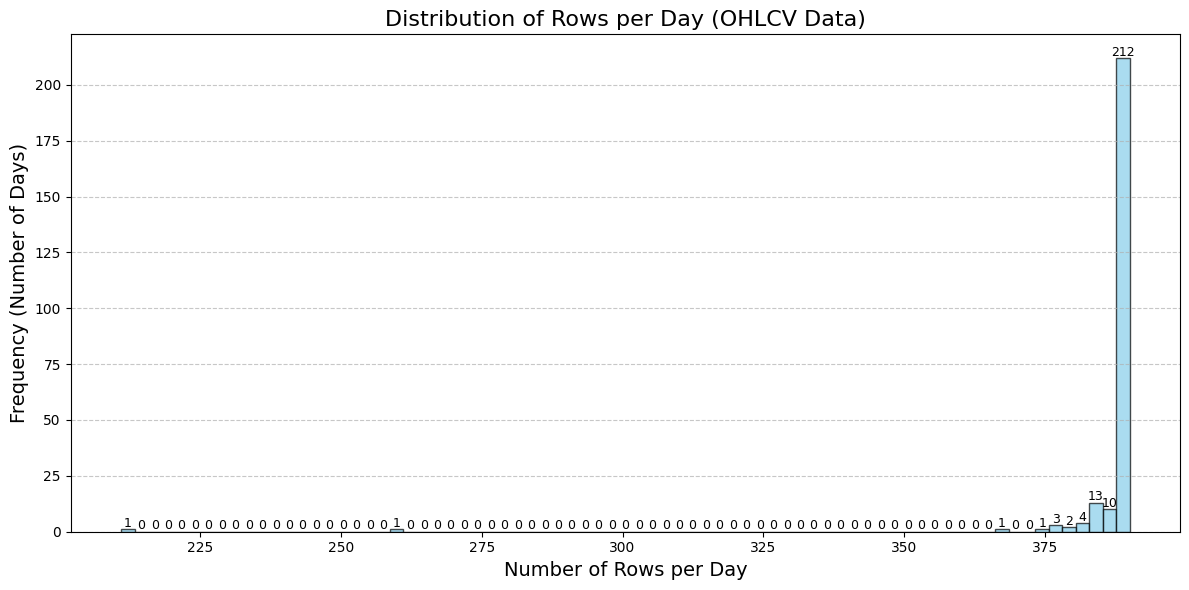

           date  row_count
243  2024-11-04        388
244  2024-11-05        376
245  2024-11-06        390
246  2024-11-07        389
247  2024-11-08        380


In [177]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df_ohlcv' is your DataFrame and 'timestamp' is the datetime column
# Create a new DataFrame for rows per day
row_count_df = (
    df_merged
    .assign(date=pd.to_datetime(df_merged['timestamp']).dt.date)  # Extract the date
    .groupby('date')
    .size()
    .reset_index(name='row_count')  # Create a new DataFrame with row counts
)

# Plot the histogram with more customization
plt.figure(figsize=(12, 6))
counts, bins, patches = plt.hist(
    row_count_df['row_count'], 
    bins=75, 
    edgecolor='black', 
    alpha=0.7, 
    color='skyblue'
)

# Add labels to the histogram bars
for count, patch, bin_start in zip(counts, patches, bins[:-1]):
    plt.text(
        bin_start + (bins[1] - bins[0]) / 2,  # X position (center of each bin)
        count + 1,  # Y position (above each bar)
        int(count),  # Text (bar height)
        ha='center', 
        fontsize=9
    )

# Add title and labels
plt.title("Distribution of Rows per Day (OHLCV Data)", fontsize=16)
plt.xlabel("Number of Rows per Day", fontsize=14)
plt.ylabel("Frequency (Number of Days)", fontsize=14)

# Add gridlines for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()

print(row_count_df.tail())




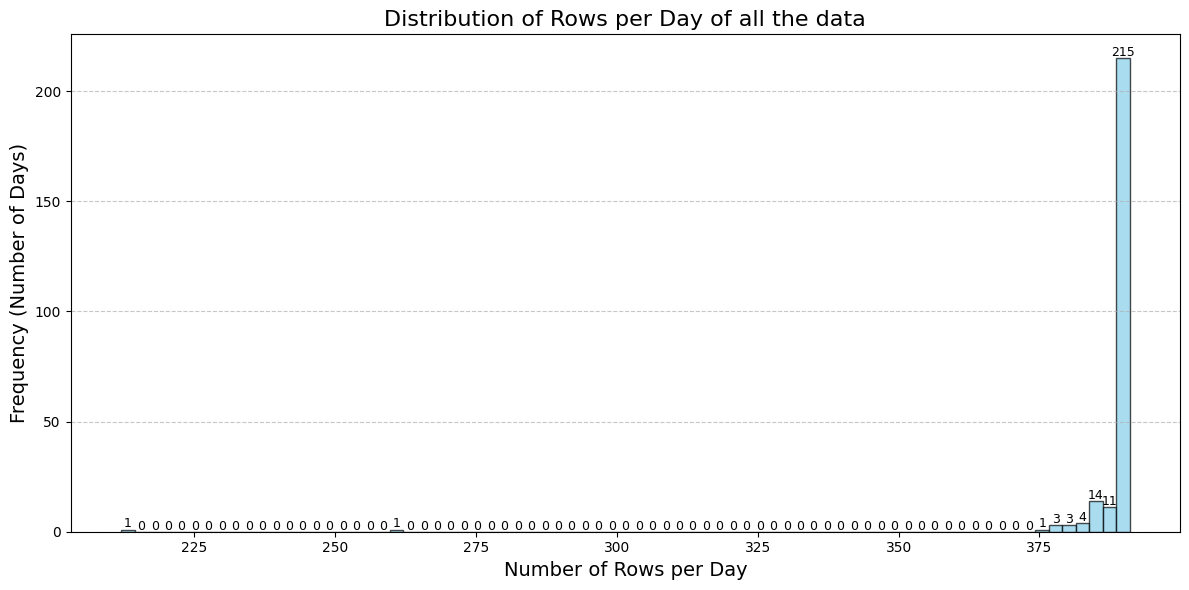

In [179]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df_ohlcv' is your DataFrame and 'timestamp' is the datetime column
# Create a new DataFrame for rows per day
row_count_df = (
    df_ohlcv
    .assign(date=pd.to_datetime(df_ohlcv['timestamp']).dt.date)  # Extract the date
    .groupby('date')
    .size()
    .reset_index(name='row_count')  # Create a new DataFrame with row counts
)

# Plot the histogram with more customization
plt.figure(figsize=(12, 6))
counts, bins, patches = plt.hist(
    row_count_df['row_count'], 
    bins=75, 
    edgecolor='black', 
    alpha=0.7, 
    color='skyblue'
)

# Add labels to the histogram bars
for count, patch, bin_start in zip(counts, patches, bins[:-1]):
    plt.text(
        bin_start + (bins[1] - bins[0]) / 2,  # X position (center of each bin)
        count + 1,  # Y position (above each bar)
        int(count),  # Text (bar height)
        ha='center', 
        fontsize=9
    )

# Add title and labels
plt.title("Distribution of Rows per Day of all the data", fontsize=16)
plt.xlabel("Number of Rows per Day", fontsize=14)
plt.ylabel("Frequency (Number of Days)", fontsize=14)

# Add gridlines for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()




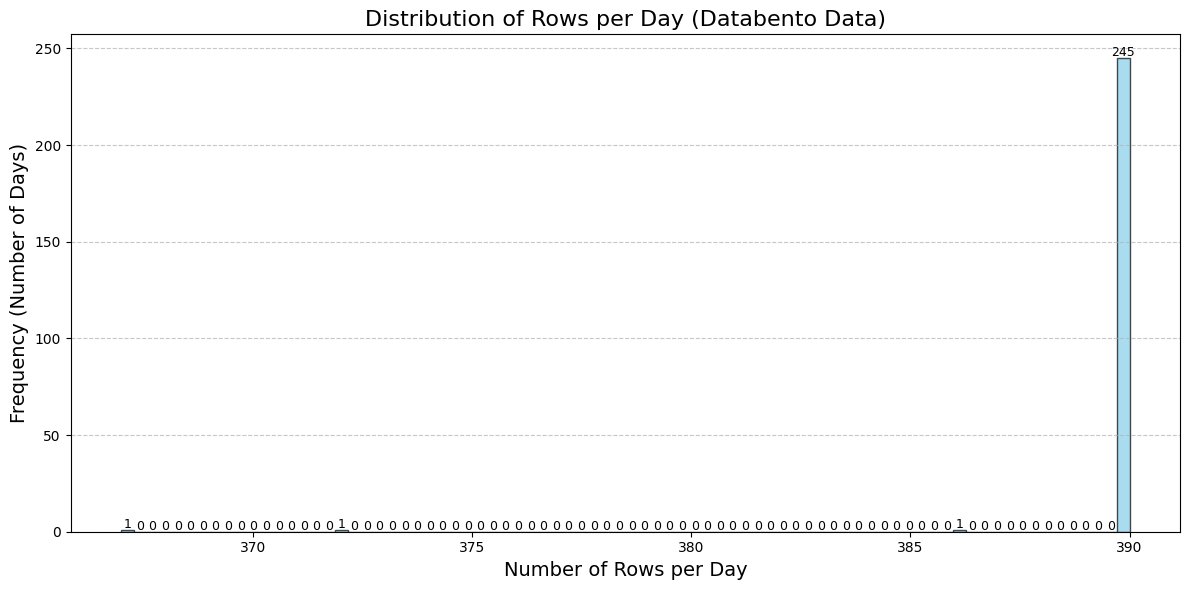

           date  row_count
243  2024-11-04        390
244  2024-11-05        390
245  2024-11-06        390
246  2024-11-07        390
247  2024-11-08        390


In [175]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df_ohlcv' is your DataFrame and 'timestamp' is the datetime column
# Create a new DataFrame for rows per day
row_count_df = (
    processed_data
    .assign(date=pd.to_datetime(processed_data['minute']).dt.date)  # Extract the date
    .groupby('date')
    .size()
    .reset_index(name='row_count')  # Create a new DataFrame with row counts
)

# Plot the histogram with more customization
plt.figure(figsize=(12, 6))
counts, bins, patches = plt.hist(
    row_count_df['row_count'], 
    bins=80, 
    edgecolor='black', 
    alpha=0.7, 
    color='skyblue'
)

# Add labels to the histogram bars
for count, patch, bin_start in zip(counts, patches, bins[:-1]):
    plt.text(
        bin_start + (bins[1] - bins[0]) / 2,  # X position (center of each bin)
        count + 1,  # Y position (above each bar)
        int(count),  # Text (bar height)
        ha='center', 
        fontsize=9
    )

# Add title and labels
plt.title("Distribution of Rows per Day (Databento Data)", fontsize=16)
plt.xlabel("Number of Rows per Day", fontsize=14)
plt.ylabel("Frequency (Number of Days)", fontsize=14)

# Add gridlines for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()
print(row_count_df.tail())



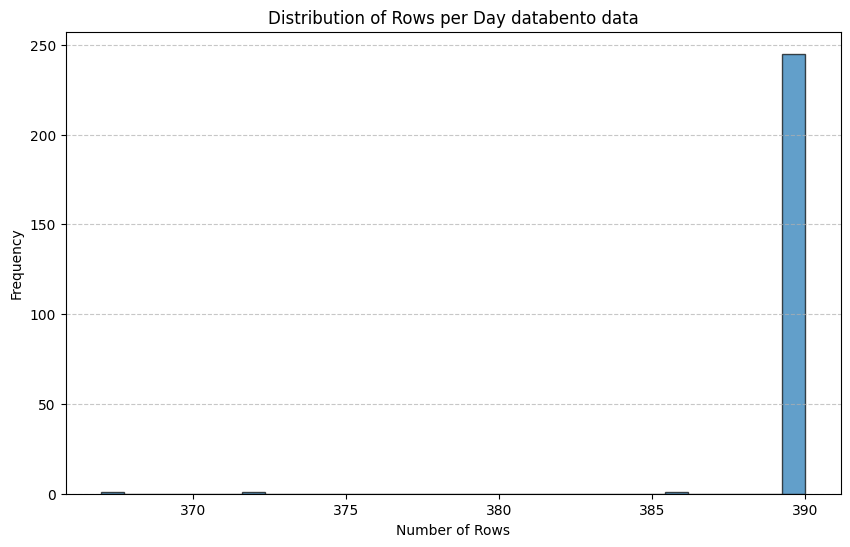

           date  row_count
243  2024-11-04        390
244  2024-11-05        390
245  2024-11-06        390
246  2024-11-07        390
247  2024-11-08        390


In [163]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'data' is your original DataFrame and 'timestamp' is the datetime column
# Create a new DataFrame for rows per day
row_count_df = (
    processed_data
    .assign(date=pd.to_datetime(processed_data['minute']).dt.date)  # Extract the date
    .groupby('date')
    .size()
    .reset_index(name='row_count')  # Create a new DataFrame with row counts
)

# Plot the histogram using the new DataFrame
plt.figure(figsize=(10, 6))
plt.hist(row_count_df['row_count'], bins=30, edgecolor='black', alpha=0.7)
plt.title("Distribution of Rows per Day databento data")
plt.xlabel("Number of Rows")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Optional: Display the new DataFrame for review
print(row_count_df.tail())

In [157]:
df_ohlcv=df_ohlcv.drop_duplicates(subset='timestamp', keep='first')

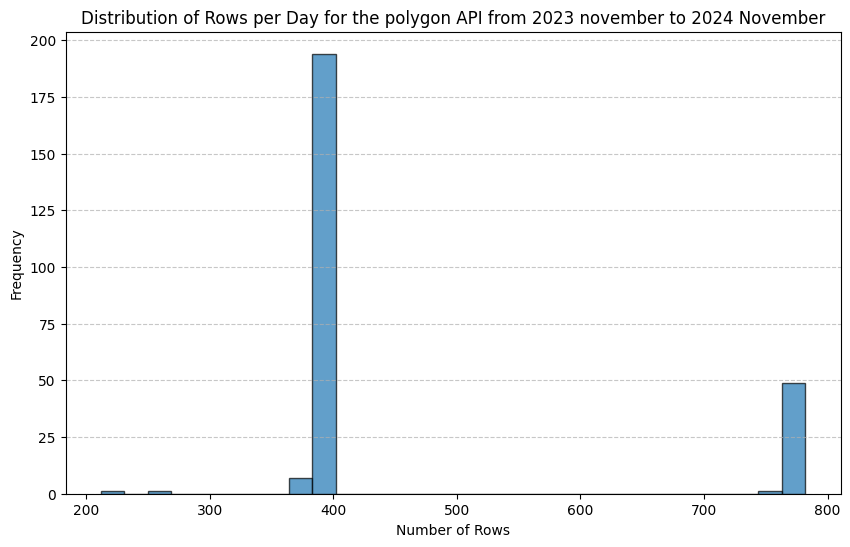

         date  row_count
0  2023-11-09        382
1  2023-11-10        387
2  2023-11-13        390
3  2023-11-14        391
4  2023-11-15        391


In [155]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'data' is your original DataFrame and 'timestamp' is the datetime column
# Create a new DataFrame for rows per day
row_count_df = (
    df_ohlcv
    .assign(date=pd.to_datetime(df_ohlcv['timestamp']).dt.date)  # Extract the date
    .groupby('date')
    .size()
    .reset_index(name='row_count')  # Create a new DataFrame with row counts
)

# Plot the histogram using the new DataFrame
plt.figure(figsize=(10, 6))
plt.hist(row_count_df['row_count'], bins=30, edgecolor='black', alpha=0.7)
plt.title("Distribution of Rows per Day for the polygon API from 2023 november to 2024 November")
plt.xlabel("Number of Rows")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Optional: Display the new DataFrame for review
print(row_count_df.head())


In [97]:
row_count_df.to_csv('rows2.csv', index=False, sep=',')

In [76]:
# Check for duplicate rows
duplicate_rows = result.duplicated().sum()
print(f"Number of exact duplicate rows: {duplicate_rows}")

# Display the first few duplicate rows (optional)
if duplicate_rows > 0:
    print("First few duplicates:")
    print(result[data.duplicated()].head())

# Remove duplicates from the dataframe
data_cleaned = result.drop_duplicates()

# Verify if duplicates have been removed
duplicate_rows_after_cleaning = data_cleaned.duplicated().sum()
print(f"Number of duplicate rows after cleaning: {duplicate_rows_after_cleaning}")

# Optional: Save the cleaned data to a new CSV file
# data_cleaned.to_csv('cleaned_data.csv', index=False)


Number of exact duplicate rows: 0
Number of duplicate rows after cleaning: 0


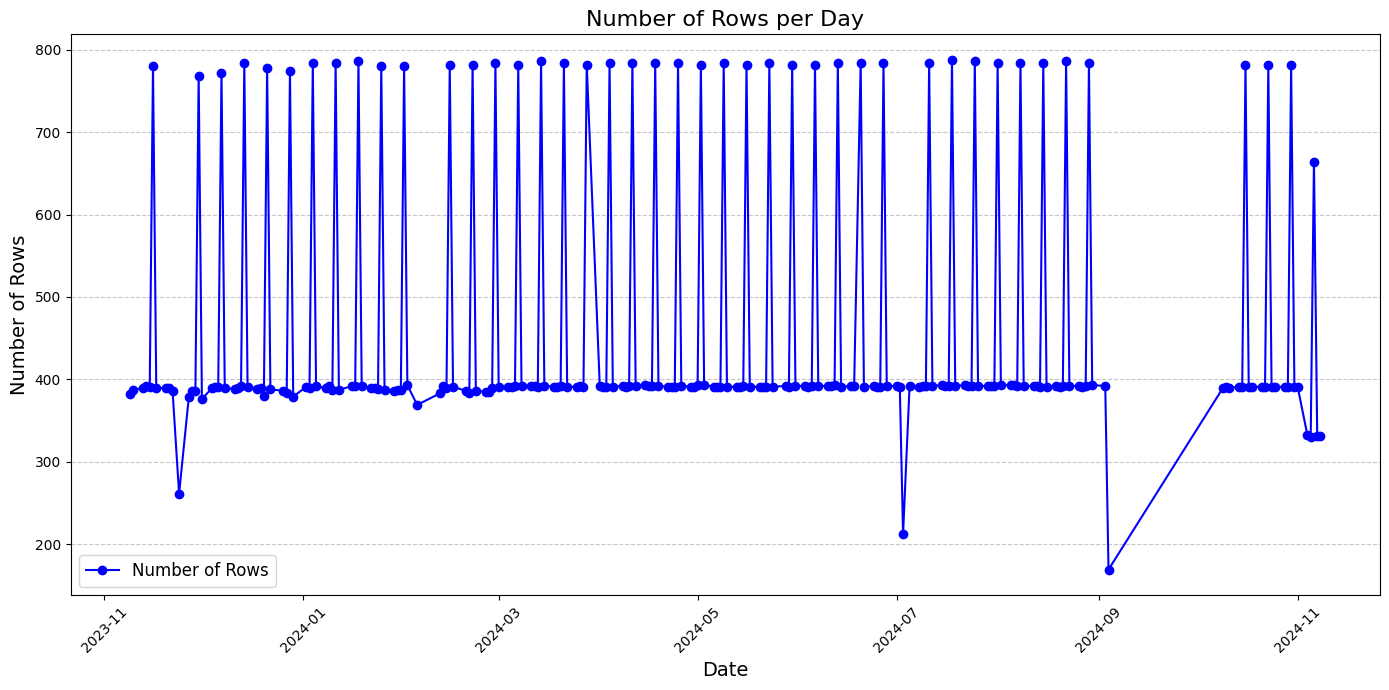

         date  row_count
0  2023-11-09        382
1  2023-11-10        387
2  2023-11-13        390
3  2023-11-14        392
4  2023-11-15        391


In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'data' is your original DataFrame and 'timestamp' is the datetime column
# Create a new DataFrame for rows per day
row_count_df = (
    result
    .assign(date=pd.to_datetime(result['timestamp']).dt.date)  # Extract the date
    .groupby('date')
    .size()
    .reset_index(name='row_count')  # Create a new DataFrame with row counts
)

# Plot a line chart for date vs. number of rows
plt.figure(figsize=(14, 7))
plt.plot(row_count_df['date'], row_count_df['row_count'], marker='o', linestyle='-', color='b', label='Number of Rows')
plt.title("Number of Rows per Day", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Number of Rows", fontsize=14)
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Optional: Display the DataFrame
print(row_count_df.head())
